# GSE114374初步分析
结肠组织基质细胞样本，4个样本，2个来自HC，2个来自UC   
2UC 2HC
- UC66-UC67
- HC87-HC88

# 文件说明
- **文件名**: 9_GSE114374.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-10-22  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/9_GSE114374_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


## 读取表达矩阵类型数据

读取HC数据

In [2]:
import pandas as pd
import os

data_dir = "/mnt/e/UC/scRNA-seq_RAW/9_GSE114374/HC"
adatas = []

for file in sorted(os.listdir(data_dir)):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(data_dir, file)
    sample = os.path.splitext(file)[0]

    df = pd.read_csv(path, sep="\t", index_col=0)
    ad = sc.AnnData(df.T)
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)

    #ad.obs['GSM_id'] = sample
    #ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names]

    adatas.append(ad)

adata1 = sc.concat(adatas, merge='same')

filtered out 9 cells that have less than 200 genes expressed
filtered out 14761 genes that are detected in less than 3 cells


In [3]:
adata1

AnnData object with n_obs × n_vars = 4369 × 18933
    obs: 'n_genes'
    var: 'n_cells'

In [4]:
adata1.obs.head()

,n_genes
AAACCTGCAAGGACTG-S66,2313
AAACCTGCACAACTGT-S66,1133
AAACCTGCACCCTATC-S66,1449
AAACCTGCAGGCTCAC-S66,1272
AAACCTGCAGTCTTCC-S66,1873


In [5]:
# 提取 sample 信息
adata1.obs["sample"] = adata1.obs_names.str.split("-").str[-1]
print("样本类别：", adata1.obs["sample"].unique())

样本类别： ['S66' 'S90']


In [6]:
# 定义映射字典
gsm_map = {"S66": "GSM3140593", "S90": "GSM3140594"}
id_map = {"S66": "HC87", "S90": "HC88"}

# 根据 sample 列进行映射生成新列
adata1.obs["GSM"] = adata1.obs["sample"].map(gsm_map)
adata1.obs["id"] = adata1.obs["sample"].map(id_map)

In [7]:
print(adata1.obs[["sample", "GSM", "id"]].drop_duplicates())

                     sample         GSM    id
AAACCTGCAAGGACTG-S66    S66  GSM3140593  HC87
AAACCTGAGATACACA-S90    S90  GSM3140594  HC88


读取UC数据

In [8]:
data_dir = "/mnt/e/UC/scRNA-seq_RAW/9_GSE114374/UC"
adatas = []

for file in sorted(os.listdir(data_dir)):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(data_dir, file)
    sample = os.path.splitext(file)[0]

    df = pd.read_csv(path, sep="\t", index_col=0)
    ad = sc.AnnData(df.T)
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)

    #ad.obs['GSM_id'] = sample
    #ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names]

    adatas.append(ad)

adata2 = sc.concat(adatas, merge='same')

filtered out 1 cells that have less than 200 genes expressed
filtered out 13828 genes that are detected in less than 3 cells


In [9]:
adata2

AnnData object with n_obs × n_vars = 4902 × 19866
    obs: 'n_genes'
    var: 'n_cells'

In [10]:
adata2.obs.head()

,n_genes
AAACCTGAGAGCTATA-S78,1473
AAACCTGAGCTAAGAT-S78,2445
AAACCTGAGGGTATCG-S78,1977
AAACCTGCACCCAGTG-S78,2558
AAACCTGCACGCATCG-S78,1556


In [11]:
# 提取 sample 信息
adata2.obs["sample"] = adata2.obs_names.str.split("-").str[-1]
print("样本类别：", adata2.obs["sample"].unique())

样本类别： ['S78' 'S54']


In [12]:
# 定义映射字典
gsm_map = {"S78": "GSM3140595", "S54": "GSM3140596"}
id_map = {"S78": "UC66", "S54": "UC67"}

# 根据 sample 列进行映射生成新列
adata2.obs["GSM"] = adata2.obs["sample"].map(gsm_map)
adata2.obs["id"] = adata2.obs["sample"].map(id_map)

In [13]:
print(adata2.obs[["sample", "GSM", "id"]].drop_duplicates())

                     sample         GSM    id
AAACCTGAGAGCTATA-S78    S78  GSM3140595  UC66
AAACCTGAGATCCGAG-S54    S54  GSM3140596  UC67


合并UC和HC数据

In [15]:
adata = sc.concat([adata1, adata2], merge="same")

In [16]:
adata

AnnData object with n_obs × n_vars = 9271 × 18216
    obs: 'n_genes', 'sample', 'GSM', 'id'

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [17]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)
adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||--------------------------- 1986/16311 MiB (12.2%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 9,271 cells × 18,216 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 13 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 2683 (range: 320-4223)
     • Mean genes: 2262 (range: 233-8885)
     • Mean mitochondrial %: 0.0% (max: 0.1%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 1 cells failed (0.0%)
     • Genes filter (≥250): 2 cells failed (0.0%)
     • Mitochondrial filter (≤0.2): 0 cells failed (0.0%)
   ✓ Combined QC filters: 2 cells removed (0.0%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_rat

AnnData object with n_obs × n_vars = 9164 × 18216
    obs: 'n_genes', 'sample', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）

In [19]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_qc/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "9_GSE114374.h5ad"), compression='gzip')

In [20]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.7)

Begin robust gene identification
After filtration, 18216/18216 genes are kept.     Among 18216 genes, 18216 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
[]
    finished (0:00:01)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 12.336138725280762 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||||----

In [21]:
adata

AnnData object with n_obs × n_vars = 9164 × 2000
    obs: 'n_genes', 'sample', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'n_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

In [22]:
adata.obs['id'].value_counts()

id
UC67    2780
HC87    2440
UC66    2064
HC88    1880
Name: count, dtype: int64

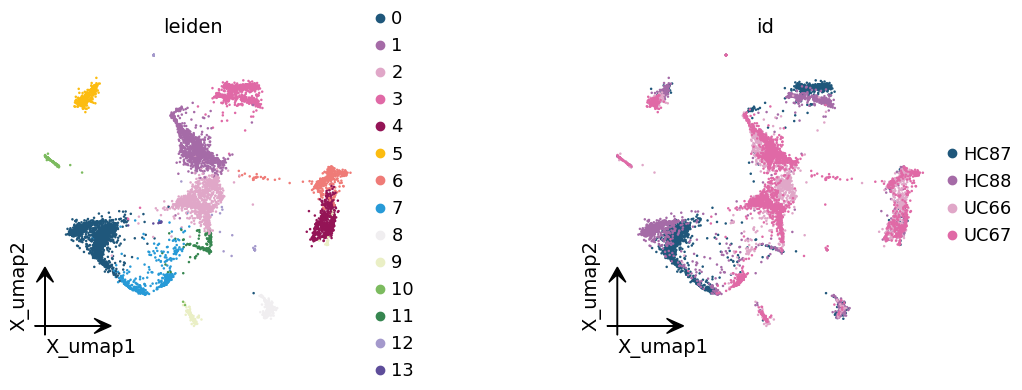

In [23]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

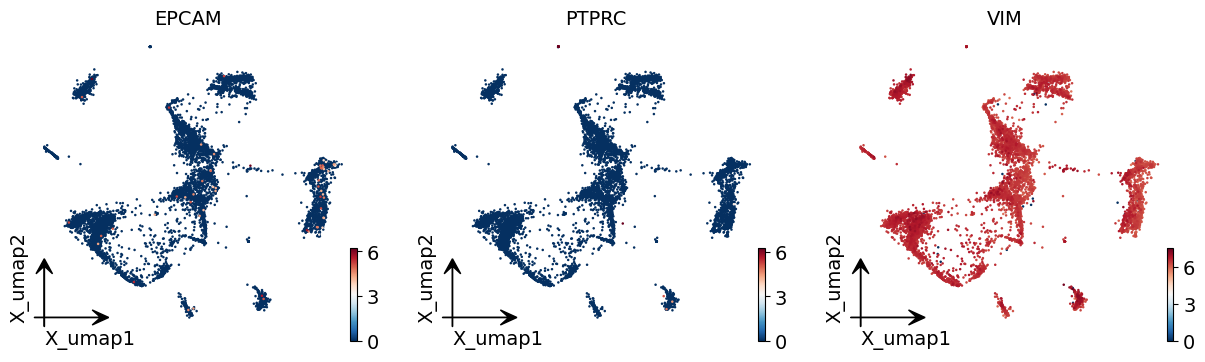

In [24]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

In [25]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:10)


{'0': ['LINC01082',
  'APOE',
  'ADAMDEC1',
  'CCL2',
  'CFD',
  'CTSC',
  'ABCA8',
  'LUM',
  'PTN',
  'DCN'],
 '1': ['C1R',
  'COL6A1',
  'SOD3',
  'F3',
  'SOD2',
  'SERPINF1',
  'CHI3L1',
  'IGFBP5',
  'COL6A2',
  'POSTN'],
 '10': ['TINAGL1',
  'LBH',
  'RERGL',
  'TAGLN',
  'NET1',
  'PHLDA2',
  'ACTA2',
  'MYL9',
  'ADIRF',
  'MYH11'],
 '11': ['ACTG2',
  'TAGLN',
  'TPM1',
  'HHIP',
  'ACTA2',
  'PDLIM3',
  'SOSTDC1',
  'MYL9',
  'MYH11',
  'MYLK'],
 '12': ['CCL21',
  'IL32',
  'LAPTM5',
  'SH3BGRL3',
  'CD3D',
  'DUSP2',
  'CD52',
  'GYPC',
  'CORO1A',
  'COTL1'],
 '13': ['ZWINT',
  'H2AFZ',
  'TK1',
  'UBE2C',
  'TYMS',
  'MAD2L1',
  'RRM2',
  'STMN1',
  'GGH',
  'KIAA0101'],
 '2': ['PDPN',
  'NAMPT',
  'SOD2',
  'C11orf96',
  'CTSK',
  'CHI3L1',
  'CTSC',
  'LUM',
  'PHLDA1',
  'CXCL1'],
 '3': ['F3',
  'PLAT',
  'BMP4',
  'NSG1',
  'HSD17B2',
  'FRZB',
  'POSTN',
  'IGFBP3',
  'EDNRB',
  'PDGFRA'],
 '4': ['PCAT19',
  'PLVAP',
  'NPDC1',
  'CD320',
  'ESAM',
  'RNASE1',
  'EGFL

In [26]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='stromal cells',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Fibroblasts, macrophages, dendritic cells',
 '1': 'Fibroblasts, pericytes',
 '10': 'Vascular smooth muscle cells, myofibroblasts',
 '11': 'Vascular smooth muscle cells',
 '12': 'T cells, dendritic cells',
 '13': 'Proliferating cells (e.g., endothelial or stromal progenitors)',
 '2': 'Fibroblasts, macrophages, adipocytes',
 '3': 'Pericytes, fibroblasts',
 '4': 'Endothelial cells',
 '5': 'Schwann cells',
 '6': 'Endothelial cells',
 '7': 'Fibroblasts, adipocytes, chondrocytes',
 '8': 'Plasma cells',
 '9': 'Pericytes, endothelial cells'}

In [27]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

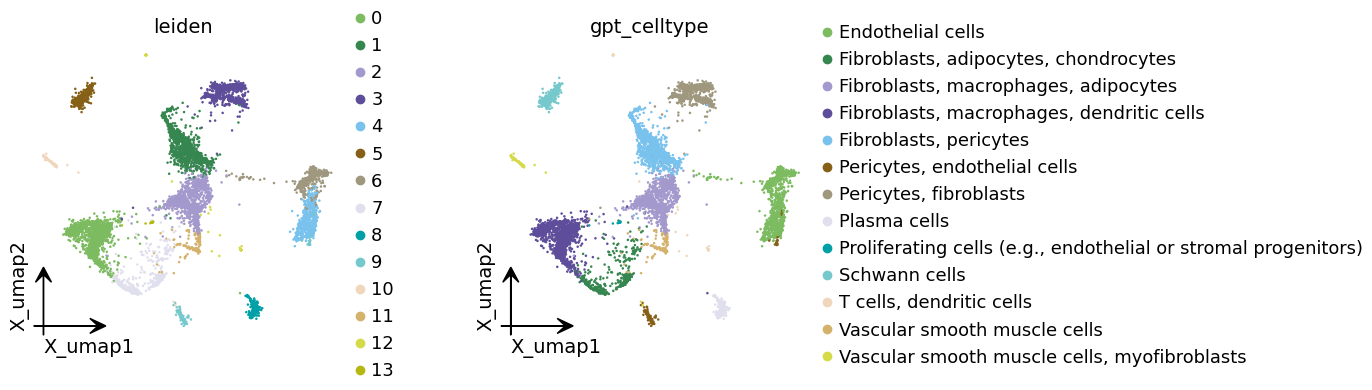

In [28]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [29]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Fibroblasts, macrophages, dendritic cells                         20.285901
Endothelial cells                                                 15.222610
Fibroblasts, pericytes                                            13.858577
Fibroblasts, macrophages, adipocytes                              13.651244
Pericytes, fibroblasts                                            10.694020
Schwann cells                                                      7.223920
Fibroblasts, adipocytes, chondrocytes                              5.597992
Plasma cells                                                       5.336098
Pericytes, endothelial cells                                       3.099083
Vascular smooth muscle cells, myofibroblasts                       2.149716
Vascular smooth muscle cells                                       1.920559
T cells, dendritic cells                                           0.752946
Proliferating cells (e.g., endothelial or stromal progenitors)     0.207333